In [1]:
# Enable Float64 for more stable matrix inversions.
from jax import (
    config,
    jit,
)
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt
import optax as ox


config.update("jax_enable_x64", True)


with install_import_hook("gpjax", "beartype.beartype"):
    import gpjax as gpx
    from gpjax.parameters import Parameter


key = jr.key(42)

cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

In [57]:
n = 2500
noise = 0.1

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=0.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: 3 * x**2 * jnp.sin(10* x) + x * jnp.cos(5 * x) + 5 * x**2
# f = lambda x: 0.5 * x

signal = f(x)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

xtest = jnp.linspace(0.0, 3.1, 500).reshape(-1, 1)
ytest = f(xtest)

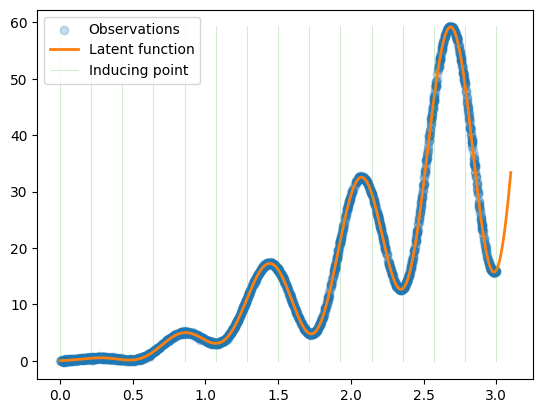

In [58]:
n_inducing = 15
z = jnp.linspace(0.0, 3.0, n_inducing).reshape(-1, 1)

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.25, label="Observations", color=cols[0])
ax.plot(xtest, ytest, label="Latent function", linewidth=2, color=cols[1])
ax.vlines(
    x=z,
    ymin=y.min(),
    ymax=y.max(),
    alpha=0.3,
    linewidth=0.5,
    label="Inducing point",
    color=cols[2],
)
ax.legend(loc="best")
plt.show()

In [59]:
meanf = gpx.mean_functions.Constant()
kernel = gpx.kernels.Matern52()# 1-dimensional inputs
likelihood = gpx.likelihoods.Gaussian(num_datapoints=D.n)
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)
posterior = prior * likelihood

In [60]:
q = gpx.variational_families.CollapsedVariationalGaussian(
    posterior=posterior, inducing_inputs=z
)

In [61]:
# Use the enhanced fit API with trainable parameter filtering
opt_posterior, history = gpx.fit(
    model=q,
    # we want want to minimize the *negative* ELBO
    objective=lambda p, d: -gpx.objectives.collapsed_elbo(p, d),
    train_data=D,
    optim=ox.adamw(learning_rate=1e-2),
    num_iters=500,
    key=key,
    trainable=Parameter,
)

  0%|          | 0/500 [00:00<?, ?it/s]

[Text(0.5, 0, 'Training iterate'), Text(0, 0.5, 'ELBO')]

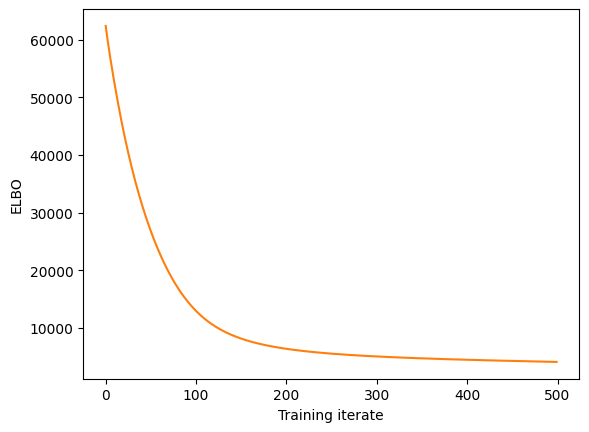

In [62]:
fig, ax = plt.subplots()
ax.plot(history, color=cols[1])
ax.set(xlabel="Training iterate", ylabel="ELBO")


/tmp/ipykernel_46286/1432928184.py:4: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  inducing_points = opt_posterior.inducing_inputs.value


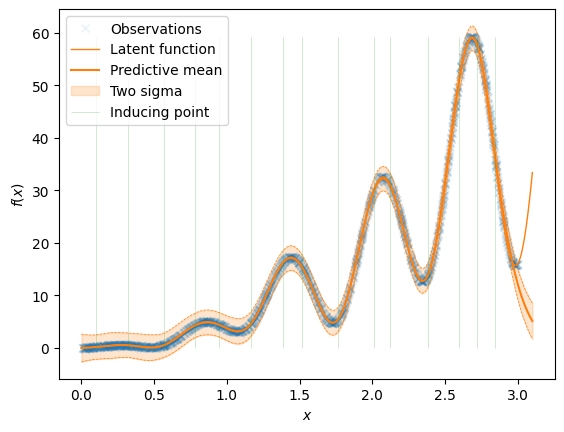

In [63]:
latent_dist = opt_posterior(xtest, train_data=D)
predictive_dist = opt_posterior.posterior.likelihood(latent_dist)

inducing_points = opt_posterior.inducing_inputs.value

samples = latent_dist.sample(key=key, sample_shape=(20,))

predictive_mean = predictive_dist.mean
predictive_std = jnp.sqrt(predictive_dist.variance)

fig, ax = plt.subplots()

ax.plot(x, y, "x", label="Observations", color=cols[0], alpha=0.1)
ax.plot(
    xtest,
    ytest,
    label="Latent function",
    color=cols[1],
    linestyle="-",
    linewidth=1,
)
ax.plot(xtest, predictive_mean, label="Predictive mean", color=cols[1])

ax.fill_between(
    xtest.squeeze(),
    predictive_mean - 2 * predictive_std,
    predictive_mean + 2 * predictive_std,
    alpha=0.2,
    color=cols[1],
    label="Two sigma",
)
ax.plot(
    xtest,
    predictive_mean - 2 * predictive_std,
    color=cols[1],
    linestyle="--",
    linewidth=0.5,
)
ax.plot(
    xtest,
    predictive_mean + 2 * predictive_std,
    color=cols[1],
    linestyle="--",
    linewidth=0.5,
)


ax.vlines(
    x=inducing_points,
    ymin=ytest.min(),
    ymax=ytest.max(),
    alpha=0.3,
    linewidth=0.5,
    label="Inducing point",
    color=cols[2],
)
ax.legend()
ax.set(xlabel=r"$x$", ylabel=r"$f(x)$")
plt.show()